# QPU machine-time analysis

On-chip **QPU runtime** for the two quantum-hardware files (`ArbTier1Full_S1_S2_1.json` — arbitrary partitions, `Tier1Full_S1_S2_1.json` — unit partitions).

The metric is `qpu_access_time_us`: the metered time the problem actually spent on the D-Wave QPU, i.e. **machine time**, not the end-to-end wall clock used in the timing notebook (which also includes cloud submission, queueing and network round-trips). Values are shown in milliseconds.

For each partition mode (arbitrary, unit, kept as separate heatmaps) and each hardware solver, a heatmap shows the mean QPU access time per (nodes × partitions) cell, in the same grid style as the timing notebook. There is no ILP baseline here — the exact ILP solve never runs on the QPU — so absolute time is shown on a single sequential colour scale (shared across the two solvers within a mode). Cells with no successful QPU run are left blank.

Plots are saved to the `plots/` directory alongside this notebook.

In [1]:
# --- Configuration -----------------------------------------------------------
# QPU machine-time analysis over the two quantum-hardware files. The metric is
# qpu_access_time_us: the metered on-chip time reported by the D-Wave QPU,
# i.e. actual machine time (NOT end-to-end wall clock). It is shown in ms.
from pathlib import Path

CANDIDATE_ROOTS = [
    Path(r"/Users/danielarturi/Desktop/Quantum/QuantumClean"),
    Path(r"/sessions/vibrant-bold-pasteur/mnt/QuantumClean"),
    Path.cwd(),
    Path.cwd().parent,
]
REPO_ROOT = next((p for p in CANDIDATE_ROOTS if (p / "result_bank").exists()), Path.cwd())

OUTPUT_DIR = Path(r"/sessions/vibrant-bold-pasteur/mnt/QuantumClean/result_analysis")
PLOTS_DIR  = Path(r"/sessions/vibrant-bold-pasteur/mnt/QuantumClean/result_analysis/plots")
if not OUTPUT_DIR.exists():
    OUTPUT_DIR = REPO_ROOT / "result_analysis"
    PLOTS_DIR  = OUTPUT_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

QPU_TIME_FIELD = "qpu_access_time_us"  # metered on-chip machine time (microseconds)

# QPU hardware files only. arbitrary and unit partition modes kept separate.
HARDWARE_FILES = {
    "arbitrary": "quantum_hardware_results_feasible/ArbTier1Full_S1_S2_1.json",
    "unit":      "quantum_hardware_results_feasible/Tier1Full_S1_S2_1.json",
}

print("Repo root :", REPO_ROOT)
print("Plots dir :", PLOTS_DIR)

Repo root : /sessions/vibrant-bold-pasteur/mnt/QuantumClean
Plots dir : /sessions/vibrant-bold-pasteur/mnt/QuantumClean/result_analysis/plots


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

## Build the QPU machine-time table

In [3]:
# --- Load + flatten the hardware files into a QPU machine-time table ----------
# One row per (partition mode, case, hardware solver). A row is kept only when
# the solver recorded a numeric qpu_access_time_us (errored cases carry no QPU
# time, so they drop out here automatically). The reference ILP solver never
# runs on the QPU and is therefore not included.
def numeric(x):
    return x if isinstance(x, (int, float)) and not isinstance(x, bool) else None

rows = []
for mode, rel in HARDWARE_FILES.items():
    path = REPO_ROOT / "result_bank" / rel
    raw = json.loads(path.read_text())
    results = raw["results"] if isinstance(raw, dict) and "results" in raw else raw
    for case_key, case in results.items():
        for sname, block in case.get("solvers", {}).items():
            if not isinstance(block, dict):
                continue
            qt = numeric(block.get(QPU_TIME_FIELD))
            if qt is None:
                continue  # ILP, or an errored run with no on-chip time
            rows.append({
                "mode": mode,
                "case": case_key,
                "solver": sname,
                "n_nodes": case.get("n_nodes"),
                "n_partitions": case.get("n_partitions"),
                "qpu_access_ms": float(qt) / 1000.0,  # us -> ms
            })

df = pd.DataFrame(rows)
print(f"{len(df)} (case x hardware-solver) QPU-time records loaded")
print(df.groupby(["mode", "solver"])["qpu_access_ms"].agg(["count", "mean", "min", "max"]).round(1))
df.head()

612 (case x hardware-solver) QPU-time records loaded
                     count   mean   min    max
mode      solver                              
arbitrary SQA_HW       150  225.2  73.4  321.7
          SQA_SF_HW    156  215.2  76.0  321.7
unit      SQA_HW       150  214.0  77.8  321.7
          SQA_SF_HW    156  209.1  73.1  321.7


,mode,case,solver,n_nodes,n_partitions,qpu_access_ms
0,arbitrary,n-3_p-12_1__t30,SQA_HW,3,12,95.73836
1,arbitrary,n-3_p-12_1__t30,SQA_SF_HW,3,12,124.68796
2,arbitrary,n-3_p-12_2__t30,SQA_HW,3,12,81.17996
3,arbitrary,n-3_p-12_2__t30,SQA_SF_HW,3,12,88.70876
4,arbitrary,n-3_p-12_3__t30,SQA_HW,3,12,133.19636


In [4]:
# --- QPU machine-time heatmap helper -----------------------------------------
# Same (rows = n_nodes, cols = n_partitions) grid as the optgap / timing maps,
# but the value is absolute mean on-chip time in ms (no baseline), so a single
# sequential colormap is used. Cells with no successful QPU run stay blank.
def fmt_ms(v):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return ""
    if v >= 100: return f"{v:.0f} ms"
    return f"{v:.1f} ms"

def qpu_heatmap(pivot, title, fname, vmin=None, vmax=None):
    if pivot.empty or pivot.isna().all().all():
        print(f"  (no QPU-time data for: {title})")
        return
    annot = np.empty(pivot.shape, dtype=object)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            annot[i, j] = fmt_ms(pivot.values[i, j])

    fig, ax = plt.subplots(figsize=(max(5, 0.8 * pivot.shape[1] + 2),
                                    max(4, 0.7 * pivot.shape[0] + 2)))
    sns.heatmap(pivot.astype(float), annot=annot, fmt="", cmap="viridis",
                vmin=vmin, vmax=vmax, linewidths=0.5, linecolor="white",
                cbar_kws={"label": "Mean QPU access time (ms)"}, ax=ax)
    ax.set_xlabel("Number of partitions")
    ax.set_ylabel("Number of nodes")
    ax.set_title(title)
    ax.invert_yaxis()
    plt.tight_layout()
    fig.savefig(PLOTS_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()

def slug(s):
    return str(s).replace(" ", "").replace("/", "_")

## QPU machine-time heatmaps

One heatmap per hardware solver, per partition mode (arbitrary and unit kept separate).


================  QPU — arbitrary partitions  (colour 84–322 ms)  ================


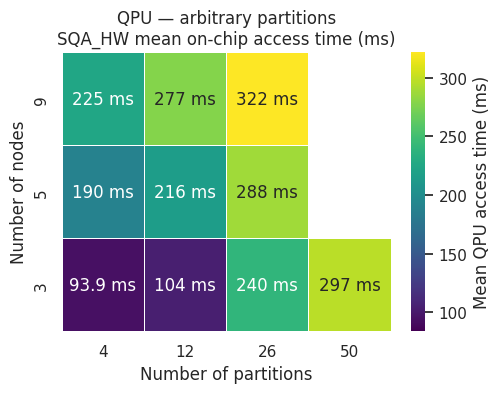

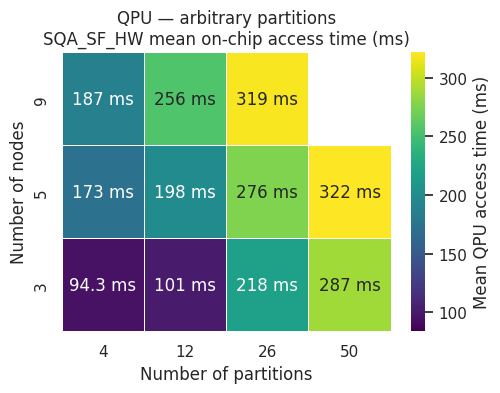


================  QPU — unit partitions  (colour 79–322 ms)  ================


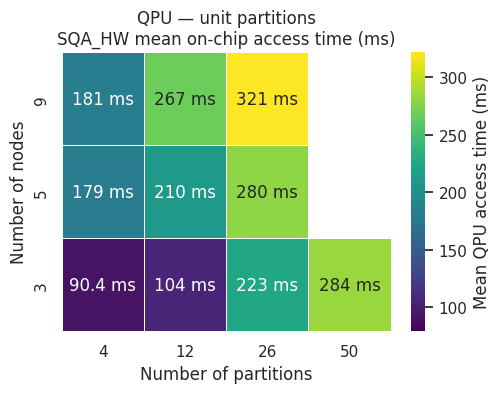

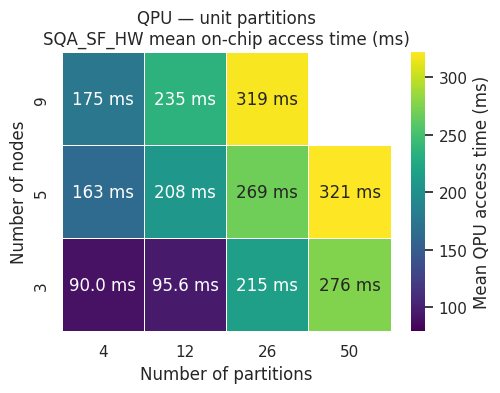

In [5]:
# --- Per partition-mode x hardware solver: absolute QPU machine-time heatmap --
# A shared colour scale per partition mode makes the two solvers directly
# comparable within that mode.
for mode in ("arbitrary", "unit"):
    sub_mode = df[df["mode"] == mode]
    if sub_mode.empty:
        print(f"[{mode}] no data")
        continue
    vmin = float(sub_mode["qpu_access_ms"].quantile(0.02))
    vmax = float(sub_mode["qpu_access_ms"].quantile(0.98))
    print(f"\n================  QPU — {mode} partitions  (colour {vmin:.0f}–{vmax:.0f} ms)  ================")
    for solver in sorted(sub_mode["solver"].unique()):
        sub = sub_mode[sub_mode["solver"] == solver]
        pivot = sub.pivot_table(index="n_nodes", columns="n_partitions",
                                values="qpu_access_ms", aggfunc="mean")
        qpu_heatmap(
            pivot,
            title=f"QPU — {mode} partitions\n{solver} mean on-chip access time (ms)",
            fname=f"qpuruntime__QPU__{mode}__{slug(solver)}__qpu_access_ms_heatmap.png",
            vmin=vmin, vmax=vmax,
        )

## Summary table

In [6]:
# --- Text summary: QPU machine time per mode/solver --------------------------
recs = []
for (mode, solver), sub in df.groupby(["mode", "solver"]):
    recs.append({
        "mode": mode, "solver": solver, "n_runs": len(sub),
        "qpu_ms_mean":   round(sub["qpu_access_ms"].mean(), 1),
        "qpu_ms_median": round(sub["qpu_access_ms"].median(), 1),
        "qpu_ms_min":    round(sub["qpu_access_ms"].min(), 1),
        "qpu_ms_max":    round(sub["qpu_access_ms"].max(), 1),
    })
summary = pd.DataFrame(recs).sort_values(["mode", "solver"]).reset_index(drop=True)
summary

,mode,solver,n_runs,qpu_ms_mean,qpu_ms_median,qpu_ms_min,qpu_ms_max
0,arbitrary,SQA_HW,150,225.2,246.2,73.4,321.7
1,arbitrary,SQA_SF_HW,156,215.2,223.4,76.0,321.7
2,unit,SQA_HW,150,214.0,228.9,77.8,321.7
3,unit,SQA_SF_HW,156,209.1,213.2,73.1,321.7
